In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [188]:
data = pd.read_csv("data/mlr.csv")
data.head(20)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
6,2014-05-02 00:00:00,335000.0,2.0,2.00,1350,2560,1.0,0,0,3,1350,0,1976,0,2616 174th Ave NE,Redmond,WA 98052,USA
7,2014-05-02 00:00:00,482000.0,4.0,2.50,2710,35868,2.0,0,0,3,2710,0,1989,0,23762 SE 253rd Pl,Maple Valley,WA 98038,USA
8,2014-05-02 00:00:00,452500.0,3.0,2.50,2430,88426,1.0,0,0,4,1570,860,1985,0,46611-46625 SE 129th St,North Bend,WA 98045,USA
9,2014-05-02 00:00:00,640000.0,4.0,2.00,1520,6200,1.5,0,0,3,1520,0,1945,2010,6811 55th Ave NE,Seattle,WA 98115,USA


In [189]:
data.shape


(4600, 18)

In [190]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [191]:
data.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [192]:
data.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [193]:
Q1= data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)

IQR = Q3-Q1

lower = Q1 - 1.5 * IQR 
upper = Q3 + 1.5 * IQR

outliers = data[
    (data['price'] <lower) |
    (data['price'] > upper )
]

print("Outliers",outliers)
print("number of outliers",len(outliers))

Outliers                      date         price  bedrooms  ...       city  statezip  country
1     2014-05-02 00:00:00  2.384000e+06       5.0  ...    Seattle  WA 98119      USA
11    2014-05-02 00:00:00  1.400000e+06       4.0  ...    Seattle  WA 98105      USA
14    2014-05-02 00:00:00  1.200000e+06       5.0  ...    Seattle  WA 98105      USA
99    2014-05-05 00:00:00  1.395000e+06       5.0  ...    Seattle  WA 98105      USA
122   2014-05-05 00:00:00  2.280000e+06       7.0  ...    Redmond  WA 98053      USA
...                   ...           ...       ...  ...        ...       ...      ...
4348  2014-05-05 00:00:00  2.199900e+06       4.0  ...  Covington  WA 98042      USA
4350  2014-07-03 00:00:00  2.659000e+07       3.0  ...       Kent  WA 98031      USA
4465  2014-06-05 00:00:00  2.560498e+06       3.0  ...    Seattle  WA 98199      USA
4467  2014-06-06 00:00:00  1.337044e+06       4.0  ...   Bellevue  WA 98004      USA
4572  2014-07-02 00:00:00  1.288333e+06       6.0  ...  

In [194]:
data_cleaned = data.drop(outliers.index)
print("original dataset",data.shape)
print("cleaned dataset",data_cleaned.shape)
print("Removed rows:",len(data)-len(data_cleaned))

original dataset (4600, 18)
cleaned dataset (4360, 18)
Removed rows: 240


In [195]:
X = data_cleaned[['bedrooms',
        'bathrooms',
        'sqft_living',
        'sqft_lot',
        'floors',
        'view',
        'condition',
        'yr_built',
        'yr_renovated']]
Y = data_cleaned['price']

In [196]:
X['city'] = data_cleaned['city']
X['statezip'] = data_cleaned['statezip']

C:\Users\Rahavi ganeshan\AppData\Local\Temp\ipykernel_17672\3491635416.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['city'] = data_cleaned['city']
C:\Users\Rahavi ganeshan\AppData\Local\Temp\ipykernel_17672\3491635416.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['statezip'] = data_cleaned['statezip']


In [197]:

print('data type',data_cleaned ['price'].dtype)
print('null values',data_cleaned ['price'].isnull().sum())
print('descrie',data_cleaned ['price'].describe())

data type float64
null values 0
descrie count    4.360000e+03
mean     4.819786e+05
std      2.205160e+05
min      0.000000e+00
25%      3.150000e+05
50%      4.475000e+05
75%      6.130000e+05
max      1.150000e+06
Name: price, dtype: float64


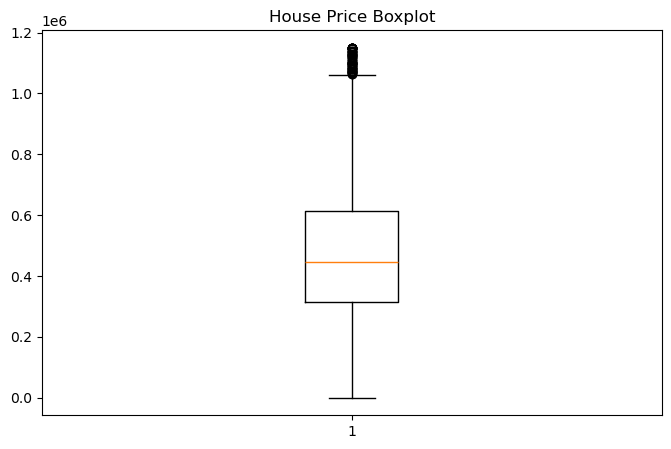

In [198]:
plt.figure(figsize=(8, 5))
plt.boxplot(data_cleaned ['price'])
plt.title('House Price Boxplot')
plt.show()


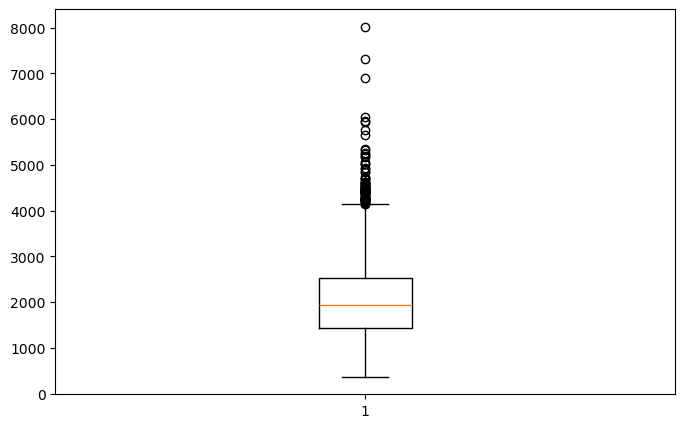

In [199]:
plt.figure(figsize=(8, 5))
plt.boxplot(data_cleaned ['sqft_living'])
plt.show()

In [200]:
print(outliers.index)

Index([   1,   11,   14,   99,  122,  133,  193,  201,  217,  227,
       ...
       4277, 4283, 4325, 4346, 4347, 4348, 4350, 4465, 4467, 4572],
      dtype='int64', length=240)


In [201]:
X = pd.get_dummies(
    X,
    columns=['city','statezip'],
    drop_first=True,
    dtype=int
)

In [202]:
X_train,X_test,Y_train,Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [203]:
model = LinearRegression()


In [204]:
model.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [205]:
Y_pred = model.predict(X_test)


In [206]:
R2_Score = r2_score(Y_test,Y_pred)
mae = mean_absolute_error(Y_test,Y_pred)
mse = mean_squared_error(Y_test,Y_pred)

print("r2_score",R2_Score)
print("Mean absolute error",mae)
print("Mean squared error",mse)

r2_score 0.6926737542295445
Mean absolute error 78509.67162181136
Mean squared error 15227277962.277773


In [207]:
comparison = pd.DataFrame({
    'Actual Price': Y_test.values,
    'Predicted Price': Y_pred
})

print(comparison.head(10))

   Actual Price  Predicted Price
0      563000.0    580119.401109
1      740000.0    624550.213235
2      875000.0    563667.622585
3      402000.0    506490.574666
4      500000.0    566419.515388
5      270000.0    290692.693926
6      443000.0    459525.803855
7      288790.0    463663.436414
8      410000.0    460670.178773
9      316000.0    304196.509567
